In [1]:
import pandas as pd
import seaborn as sns

#load dataset
df = sns.load_dataset('titanic')

df.to_csv("titanic.csv",index = False)

print("shape:",df.shape)
print("\n--- df.info() ---")
df.info()

print("\n--- describe() ---")
print(df.describe())

missing_pct = (df.isna().sum() / len(df)) * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)

print("\n--- missing value percentages ---")
print(missing_pct)


shape: (891, 15)

--- df.info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB

--- describe() ---
         survived      

#Task-2

In [2]:
print("Row before cleaning:", df.shape[0])

print(f"\n embarking missing: {missing_pct['embarked']:.2f}% -> dropping affected rows")
df = df.dropna(subset=["embarked"])

print(f"\n embark_town missing: {missing_pct['embark_town']:.2f}% -> dropping affected rows")
df = df.dropna(subset=["embark_town"])

print("\n Rows after dropping embarked/embark_town nulls",df.shape[0])


print(f"\n age missing: {missing_pct['age']:.2f}% -> between 5%-30% -> imputing with median")
age_median = df["age"].median()
df["age"] = df["age"].fillna(age_median)
print(f"Age imputed with median value: {age_median}")

print(f"\n deck missing: {missing_pct['deck']:.2f}% -> too high for reliable imputation")
print("Decision: encode missing as its own category 'unknown' rather than dropping the column")
print("Since deck may still carry signal (e.g. correlating with passenger class)")

df["deck"] = df["deck"].astype(str)
df["deck"] = df["deck"].replace("nan", "unknown")

print("\n Missing values remaning:")
print(df[["age", "embarked", "embark_town", "deck"]].isna().sum())

print("\n Final shape after cleaning:", df.shape)

Row before cleaning: 891

 embarking missing: 0.22% -> dropping affected rows

 embark_town missing: 0.22% -> dropping affected rows

 Rows after dropping embarked/embark_town nulls 889

 age missing: 19.87% -> between 5%-30% -> imputing with median
Age imputed with median value: 28.0

 deck missing: 77.22% -> too high for reliable imputation
Decision: encode missing as its own category 'unknown' rather than dropping the column
Since deck may still carry signal (e.g. correlating with passenger class)

 Missing values remaning:
age            0
embarked       0
embark_town    0
deck           0
dtype: int64

 Final shape after cleaning: (889, 15)


#Task-3

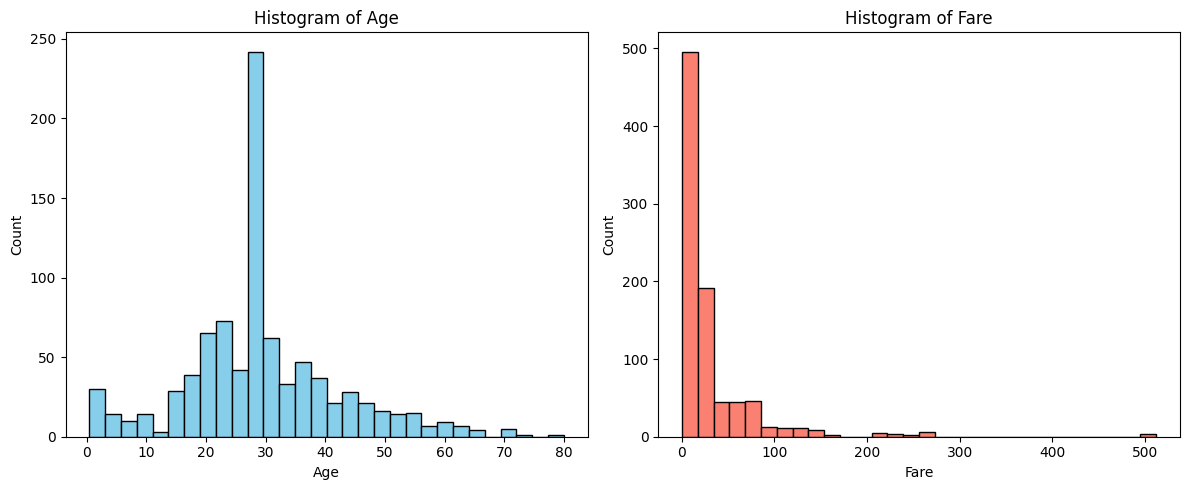

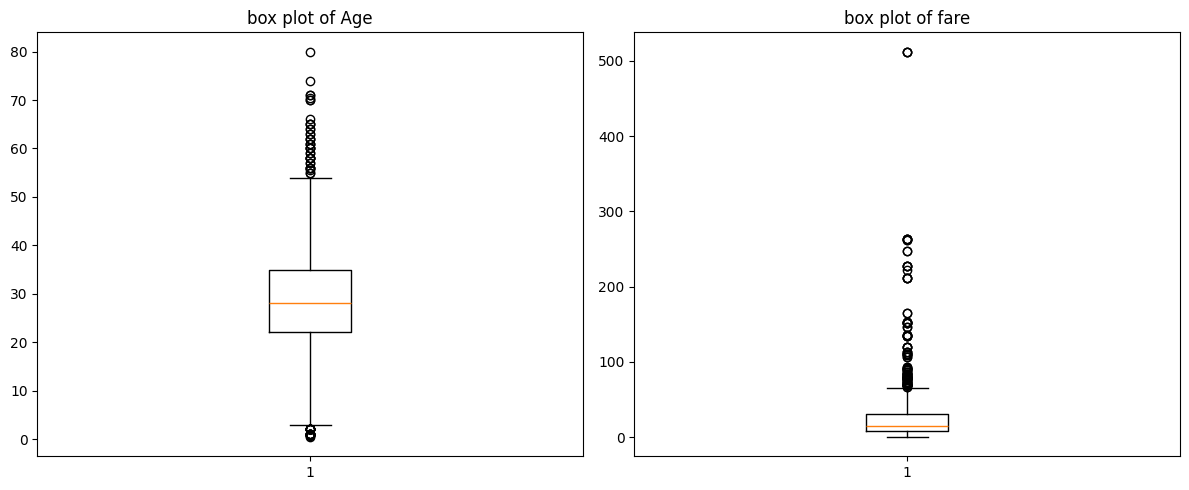

Age outliers: 65 (bounds: 2.50 to 54.50)
Fare outliers: 114 (bounds: -26.76 to 65.66)

 Fare - mean: 32.10, Median: 14.45, mode: 8.05

 Fare distribution is: right-skewed (mean > median > mode) - a long tail of high fares pulls the mean upward


In [3]:
import matplotlib.pyplot as plt

# Histogram
fig , axes = plt.subplots(1,2, figsize=(12, 5))
axes[0].hist(df["age"], bins=30, color="skyblue", edgecolor="black")
axes[0].set_title("Histogram of Age")
axes[0].set_xlabel("Age")
axes[0].set_ylabel("Count")

axes[1].hist(df["fare"], bins=30, color="salmon", edgecolor="black")
axes[1].set_title("Histogram of Fare")
axes[1].set_xlabel("Fare")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.savefig("hist_age_fare.png")
plt.show()

#  Box plots
fig , axes = plt.subplots(1,2, figsize=(12, 5))
axes[0].boxplot(df["age"])
axes[0].set_title("box plot of Age")

axes[1].boxplot(df["fare"])
axes[1].set_title("box plot of fare")

plt.tight_layout()
plt.savefig("box_age_fare.png")
plt.show()

# IQR-based outlier detection
def count_outliers_iqr(series):
  Q1 = series.quantile(0.25)
  Q3 = series.quantile(0.75)
  IQR = Q3 -Q1
  lower_bound = Q1 - 1.5 * IQR
  upper_bound = Q3 + 1.5 * IQR
  outliers = series[(series < lower_bound) | (series > upper_bound)]
  return len(outliers), lower_bound, upper_bound

age_outlier_count, age_lb, age_ub = count_outliers_iqr(df["age"])
fare_outlier_count, fare_lb, fare_ub = count_outliers_iqr(df["fare"])

print(f"Age outliers: {age_outlier_count} (bounds: {age_lb:.2f} to {age_ub:.2f})")
print(f"Fare outliers: {fare_outlier_count} (bounds: {fare_lb:.2f} to {fare_ub:.2f})")


# mean,median,mode for fare
fare_mean = df["fare"].mean()
fare_median = df["fare"].median()
fare_mode = df["fare"].mode()[0]

print(f"\n Fare - mean: {fare_mean:.2f}, Median: {fare_median:.2f}, mode: {fare_mode:.2f}")

if fare_mean > fare_median > fare_mode:
  skew_conclusion = "right-skewed (mean > median > mode) - a long tail of high fares pulls the mean upward"
elif fare_mean < fare_median < fare_mode:
  skew_conclusion = "left-skewed (mean < median < mode) - a long tail of low fares pulls the mean downward"
else:
  skew_conclusion = "approximately symmetric (mean ~ median ~ mode)"

print(f"\n Fare distribution is: {skew_conclusion}")

# Task-4

 survival rate by sex
Male : 18.89%
female : 74.04%

 survival rate by pclass
class 1: 62.62%
class 2: 47.28%
class 3: 24.24%

 survival rate by sex and pclass combined
male, class 1: 36.89%
male, class 2: 15.74%
male, class 3: 13.54%
female, class 1: 96.74%
female, class 2: 92.11%
female, class 3: 50.00%

 correlation matrix
          survived    pclass       age     sibsp     parch      fare
survived  1.000000 -0.335549 -0.069822 -0.034040  0.083151  0.255290
pclass   -0.335549  1.000000 -0.336512  0.081656  0.016824 -0.548193
age      -0.069822 -0.336512  1.000000 -0.232543 -0.171485  0.093707
sibsp    -0.034040  0.081656 -0.232543  1.000000  0.414542  0.160887
parch     0.083151  0.016824 -0.171485  0.414542  1.000000  0.217532
fare      0.255290 -0.548193  0.093707  0.160887  0.217532  1.000000


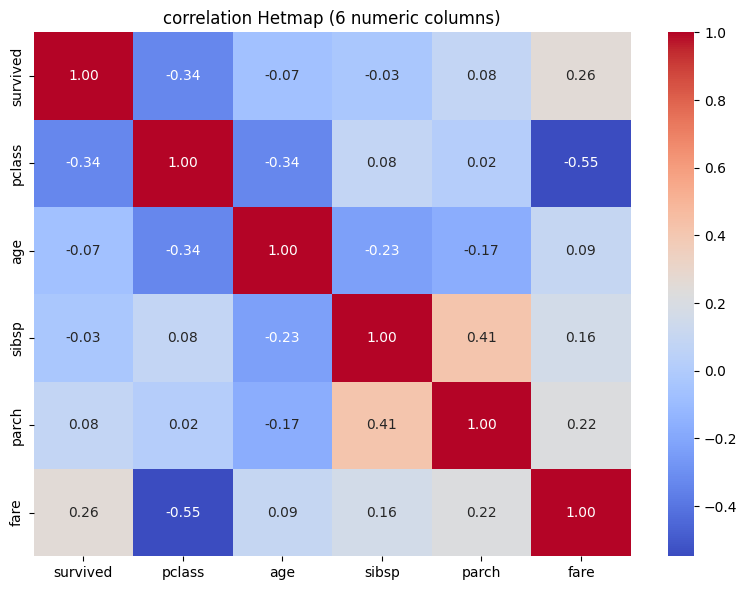


 Top 2 strongest correlation
   feature_1 feature_2  correlation  abs_correlation
8     pclass      fare    -0.548193         0.548193
12     sibsp     parch     0.414542         0.414542


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

male_survival_rate = df[df["sex"] == "male"]["survived"].mean()
female_survival_rate = df[df["sex"] == "female"]["survived"].mean()

print(" survival rate by sex")
print(f"Male : {male_survival_rate:.2%}")
print(f"female : {female_survival_rate:.2%}")

print("\n survival rate by pclass")
for pclass in sorted(df["pclass"].unique()):
  rate = df[df["pclass"] == pclass]["survived"].mean()
  print(f"class {pclass}: {rate:.2%}")


print("\n survival rate by sex and pclass combined")
for sex in ["male","female"]:
  for pclass in sorted(df["pclass"].unique()):
    mask = (df["sex"] ==  sex) & (df["pclass"] == pclass)
    rate = df[mask]["survived"].mean()
    print(f"{sex}, class {pclass}: {rate:.2%}")


corr_cols = ["survived", "pclass", "age", "sibsp", "parch", "fare"]
corr_matrix = df[corr_cols].corr()

print("\n correlation matrix")
print(corr_matrix)

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("correlation Hetmap (6 numeric columns)")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.show()


corr_pairs = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
corr_pairs = corr_pairs.stack().reset_index()
corr_pairs.columns = ["feature_1", "feature_2", "correlation"]
corr_pairs["abs_correlation"] = corr_pairs["correlation"].abs()
corr_pairs = corr_pairs.sort_values("abs_correlation", ascending = False)

print("\n Top 2 strongest correlation")
print(corr_pairs.head(2))

#Task-5

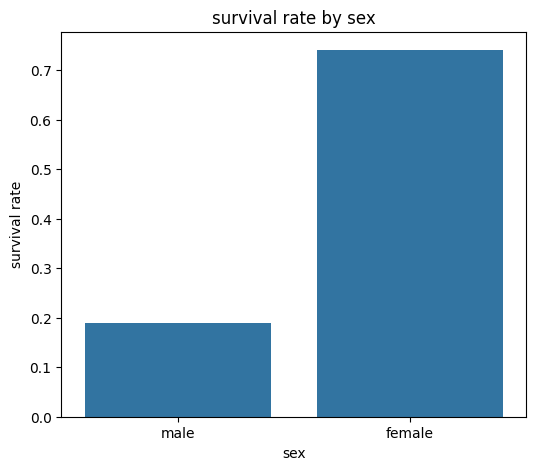


Interpretataion: Women had a dramatically higher survival rate thatmen (bout 74% vc 19%).
This reflects the "women and children first" evacuation priority followed during the Titanic
disaster. sex alone appears to be one of the strongest single predictord of survival in this
dataset.



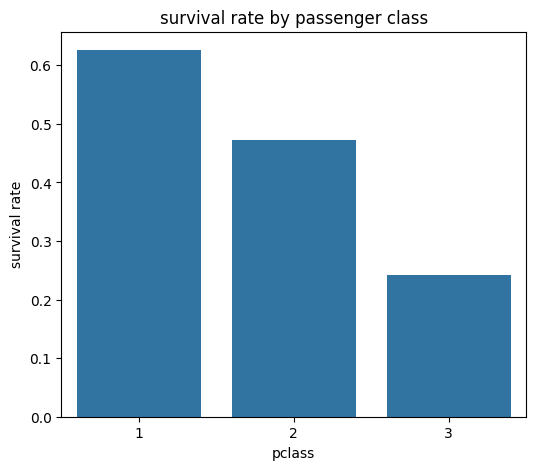


Interpretataion: Survival rate drops steadily from 1st class (63%) to 2nd class (47%) to 3rd
class (24%). This suggests that wealthier passengers, had a substantial survival advantage over
lower-class passengers.



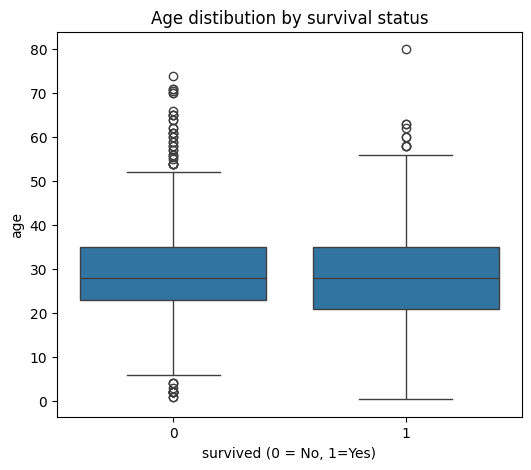


Interpretation: The age distributions of survivors and non-survivors are fairly similar overall,
but suvivors skew slighlty youonger, and the presence of young child among survivors is visible.
this supports the idea that childern were somewhat prioritized during evacuation, through age alone is a weker predictor than sex or class.



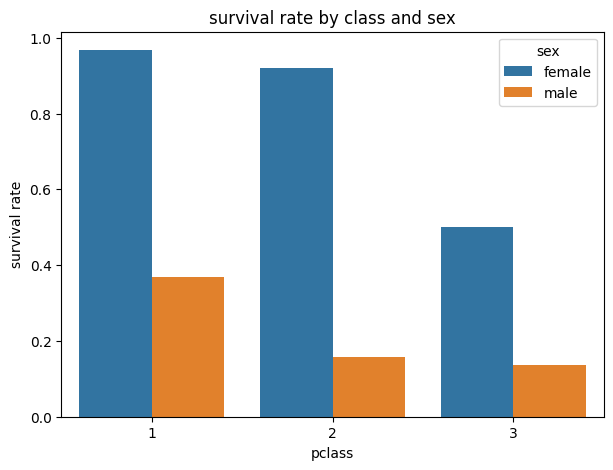


Interpretation: combining sex and class reveals the starkest patternin th edata: 1st and 2nd class women survived
at over90%, while 3rd class men survived at onlt 14%. This shows that sex and class effects.being both female and wealthly provived the more
survival advantage,  while being both male and poor was the disadvantage combination.



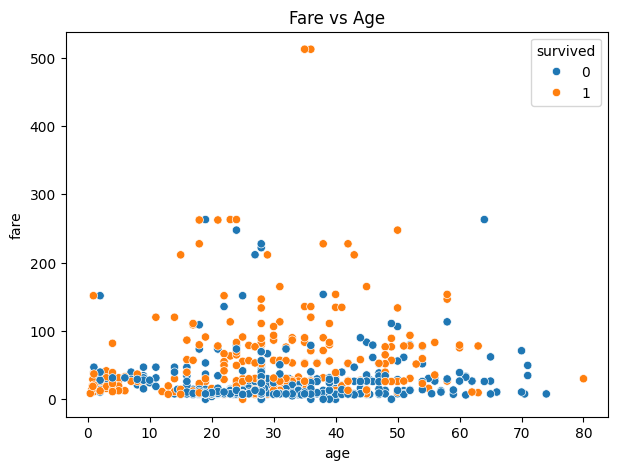


Interpretation: Survivors are noticeably concentrated at higher fare values.
Age shows no clear seperation between survivors and non-survivors,
confirming that fare or class was a much stronger fact in survival than age
alone.



In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# chat-1
plt.figure(figsize=(6, 5))
sns.barplot(data=df , x="sex", y="survived", errorbar=None)
plt.title("survival rate by sex")
plt.ylabel("survival rate")
plt.savefig("chart1_survival_by_sex.png")
plt.show()

print("""
Interpretataion: Women had a dramatically higher survival rate thatmen (bout 74% vc 19%).
This reflects the "women and children first" evacuation priority followed during the Titanic
disaster. sex alone appears to be one of the strongest single predictord of survival in this
dataset.
""")

# chart-2
plt.figure(figsize=(6, 5))
sns.barplot(data=df , x="pclass", y="survived", errorbar=None)
plt.title("survival rate by passenger class")
plt.ylabel("survival rate")
plt.savefig("chart2_survival_by_pclass.png")
plt.show()

print("""
Interpretataion: Survival rate drops steadily from 1st class (63%) to 2nd class (47%) to 3rd
class (24%). This suggests that wealthier passengers, had a substantial survival advantage over
lower-class passengers.
""")

# chart-3
plt.figure(figsize=(6, 5))
sns.boxplot(data=df , x="survived", y="age")
plt.title("Age distibution by survival status")
plt.xlabel("survived (0 = No, 1=Yes)")
plt.savefig("chart3_age_by_survival.png")
plt.show()

print("""
Interpretation: The age distributions of survivors and non-survivors are fairly similar overall,
but suvivors skew slighlty youonger, and the presence of young child among survivors is visible.
this supports the idea that childern were somewhat prioritized during evacuation, through age alone is a weker predictor than sex or class.
""")

# chart-4
plt.figure(figsize=(7, 5))
sns.barplot(data=df , x="pclass", y="survived", hue="sex", errorbar=None)
plt.title("survival rate by class and sex")
plt.ylabel("survival rate")
plt.savefig("chart4_survival_by_class_and_sex.png")
plt.show()

print("""
Interpretation: combining sex and class reveals the starkest patternin th edata: 1st and 2nd class women survived
at over90%, while 3rd class men survived at onlt 14%. This shows that sex and class effects.being both female and wealthly provived the more
survival advantage,  while being both male and poor was the disadvantage combination.
""")

# chart-5
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df , x="age", y="fare", hue="survived")
plt.title("Fare vs Age")
plt.savefig("chart5_fare_vs_age_survival.png")
plt.show()

print("""
Interpretation: Survivors are noticeably concentrated at higher fare values.
Age shows no clear seperation between survivors and non-survivors,
confirming that fare or class was a much stronger fact in survival than age
alone.
""")


#Task-6

Before standardization
Age = mean: 29.32, std: 12.98
Fare = mean: 32.10, std: 49.70

 After standardization
Age_score = mean: 0.00, std: 1.00
fare_score = mean: 0.00, std: 1.00


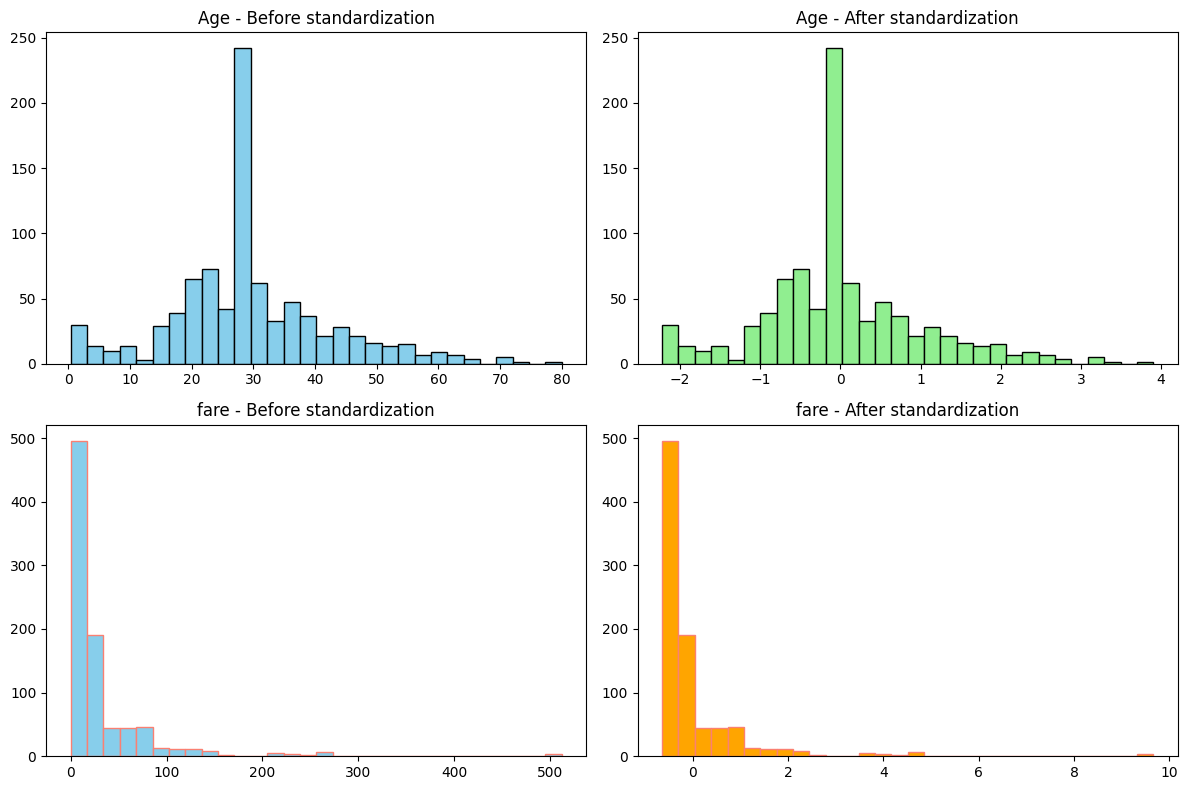

In [6]:
print("Before standardization")
print(f"Age = mean: {df['age'].mean():.2f}, std: {df['age'].std():.2f}")
print(f"Fare = mean: {df['fare'].mean():.2f}, std: {df['fare'].std():.2f}")

df["age_score"] = (df["age"] - df["age"].mean())/ df["age"].std()
df["fare_score"] = (df["fare"] - df["fare"].mean())/ df["fare"].std()

print("\n After standardization")
print(f"Age_score = mean: {df['age_score'].mean():.2f}, std: {df['age_score'].std():.2f}")
print(f"fare_score = mean: {df['fare_score'].mean():.2f}, std: {df['fare_score'].std():.2f}")

fig, axes = plt.subplots(2,2, figsize=(12, 8))

axes[0, 0].hist(df["age"], bins=30, color="skyblue", edgecolor="black")
axes[0, 0].set_title("Age - Before standardization")

axes[0, 1].hist(df["age_score"], bins=30, color="lightgreen", edgecolor="black")
axes[0, 1].set_title("Age - After standardization")

axes[1, 0].hist(df["fare"], bins=30, color="skyblue", edgecolor="salmon")
axes[1, 0].set_title("fare - Before standardization")

axes[1, 1].hist(df["fare_score"], bins=30, color="orange", edgecolor="salmon")
axes[1, 1].set_title("fare - After standardization")

plt.tight_layout()
plt.savefig("standardization_before_after.png")
plt.show()

##part-B

#Task-1

In [7]:
from sklearn.model_selection import train_test_split

x = df.drop(columns=["survived", "age_score", "fare_score"])
y = df["survived"]

x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42, stratify=y

)

print("Train set size:", x_train.shape[0])
print("Test set size:", x_test.shape[0])

print("\n Survival rate in full dataset:", y.mean().round(4))
print("Survival rate in train set:", y_train.mean().round(4))
print("Survival rate in test set:", y_test.mean().round(4))

Train set size: 711
Test set size: 178

 Survival rate in full dataset: 0.3825
Survival rate in train set: 0.3826
Survival rate in test set: 0.382


#Task-2

In [8]:
from sklearn.model_selection import train_test_split

feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]

x = df[feature_cols]
y = df["survived"]

x_train, x_test, y_train, y_test = train_test_split(
    x,y,test_size=0.2, random_state=42, stratify=y

)

print("Train set size:", x_train.shape[0])
print("Test set size:", x_test.shape[0])
print("\n olumns used:", list(x.columns))
print("\n Missing values in x_train:\n", x_train.isna().sum())

Train set size: 711
Test set size: 178

 olumns used: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

 Missing values in x_train:
 pclass      0
sex         0
age         0
sibsp       0
parch       0
fare        0
embarked    0
dtype: int64


In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = ["pclass", "age", "sibsp", "parch", "fare"]
categorical_features = ["sex", "embarked"]

numeric_transformer = Pipeline(steps =[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])


preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

print("Processed train shape:", x_train_processed.shape)
print("processed test shape:", x_test_processed.shape)

Processed train shape: (711, 10)
processed test shape: (178, 10)


#task-3

All 3 models trained successfully


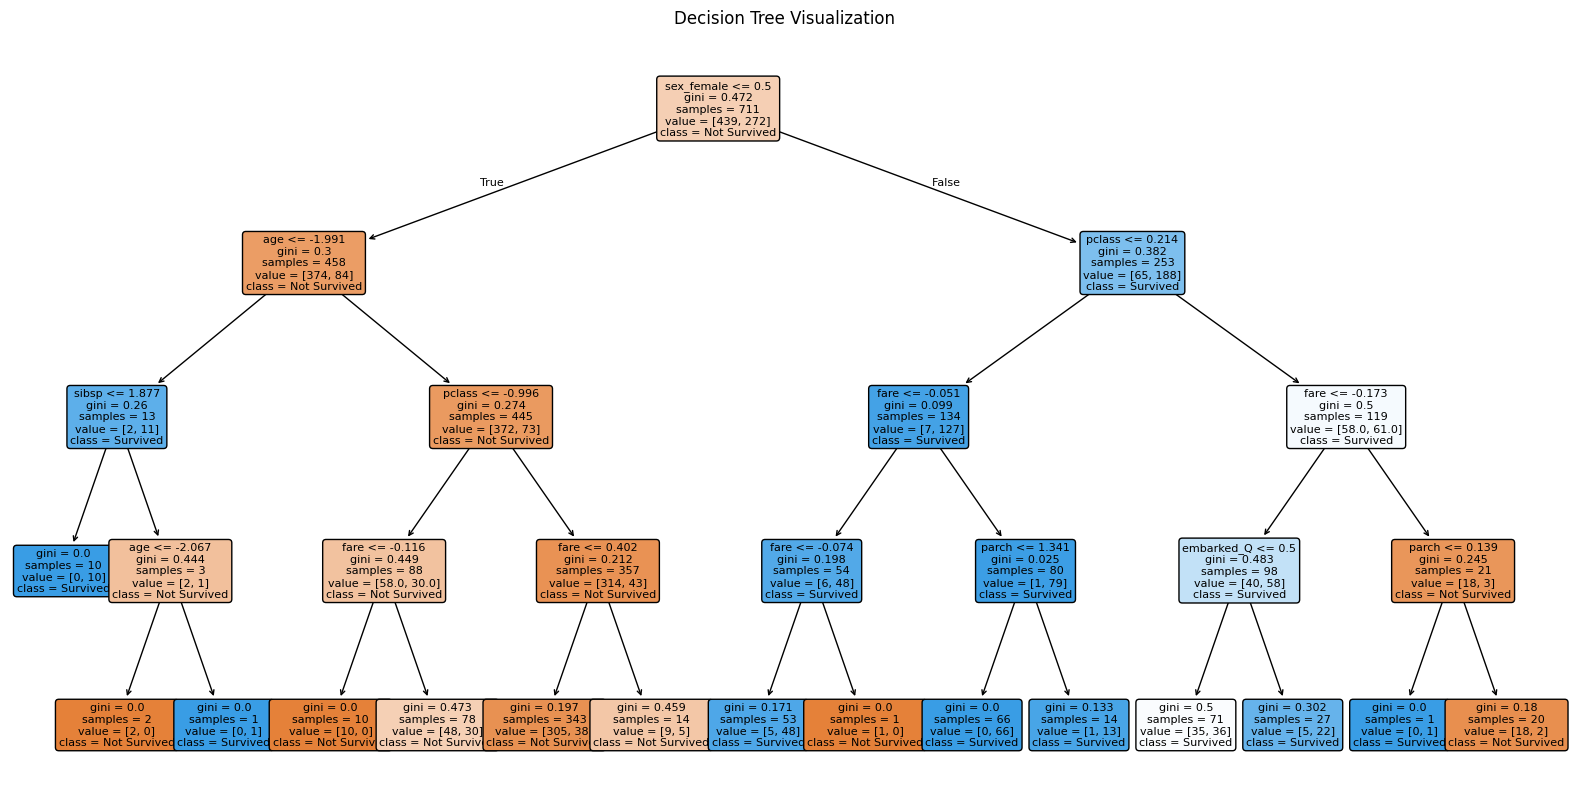

In [10]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(x_train_processed, y_train)

dec_tree = DecisionTreeClassifier(random_state=42, max_depth=4)
dec_tree.fit(x_train_processed, y_train)


random_forest = RandomForestClassifier(random_state=42, n_estimators=100)
random_forest.fit(x_train_processed, y_train)

print("All 3 models trained successfully")

feature_names = (
    numeric_features +
    list(preprocessor.named_transformers_["cat"]["encoder"].get_feature_names_out(categorical_features))
)

plt.figure(figsize=(20, 10))
plot_tree(
    dec_tree,
    feature_names=feature_names,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)


plt.title("Decision Tree Visualization")
plt.savefig("decision_tree.png")
plt.show()

#Task-4

--- Logistic Regression ---
confusion matrix:
[[97 13]
 [21 47]]
Accuracy: 0.8090 | Precision: 0.7833 | Recall: 0.6912 | F1: 0.7344 | AUC: 0.8610

--- Decision Tree ---
confusion matrix:
[[100  10]
 [ 24  44]]
Accuracy: 0.8090 | Precision: 0.8148 | Recall: 0.6471 | F1: 0.7213 | AUC: 0.8560

--- Random Forest ---
confusion matrix:
[[96 14]
 [18 50]]
Accuracy: 0.8202 | Precision: 0.7812 | Recall: 0.7353 | F1: 0.7576 | AUC: 0.8179



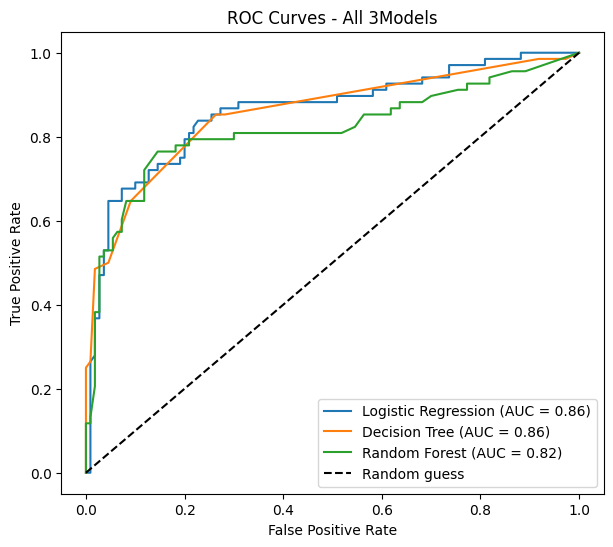


--- MOdel Comparison Table ---
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8090     0.7833  0.6912  0.7344  0.8610
1        Decision Tree    0.8090     0.8148  0.6471  0.7213  0.8560
2        Random Forest    0.8202     0.7812  0.7353  0.7576  0.8179


In [11]:
from sklearn.metrics import(
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, roc_curve, roc_auc_score
)
import pandas as pd
import matplotlib.pyplot as plt

models = {
    "Logistic Regression": log_reg,
    "Decision Tree": dec_tree,
    "Random Forest": random_forest
}

results = []

plt.figure(figsize=(7, 6))

for name, model in models.items():
  y_pred = model.predict(x_test_processed)
  y_proba = model.predict_proba(x_test_processed)[:,1]

  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_proba)

  cm = confusion_matrix(y_test, y_pred)
  print(f"--- {name} ---")
  print("confusion matrix:")
  print(cm)
  print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | AUC: {auc:.4f}\n")

  results.append({
      "Model": name,
      "Accuracy": round(acc, 4),
      "Precision": round(prec, 4),
      "Recall": round(rec, 4),
      "F1": round(f1, 4),
      "AUC": round(auc, 4)
  })

  fpr, tpr, thresholds = roc_curve(y_test, y_proba)
  plt.plot(fpr, tpr, label = f"{name} (AUC = {auc:.2f})")

plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - All 3Models")
plt.legend()
plt.savefig("roc_curves.png")
plt.show()


comparison_df = pd.DataFrame(results)
print("\n--- MOdel Comparison Table ---")
print(comparison_df)

#Task-5

In [12]:
from sklearn.linear_model import LogisticRegression
from imblearn.over_sampling import SMOTE
from sklearn.metrics import precision_score, recall_score, f1_score

print("--- Class balance in training set --- ")
print(y_train.value_counts())
print(y_train.value_counts(normalize=True).round(4))

imbalance_results = []

model_baseline = LogisticRegression(random_state=42, max_iter=1000)
model_baseline.fit(x_train_processed, y_train)
y_pred_baseline = model_baseline.predict(x_test_processed)

imbalance_results.append({
    "Starategy": "Baseline (no handling)",
    "Precision": round(precision_score(y_test,  y_pred_baseline), 4),
    "Recall": round(recall_score(y_test,  y_pred_baseline), 4),
    "F1": round(f1_score(y_test,  y_pred_baseline), 4)
})

model_balanced = LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced")
model_balanced.fit(x_train_processed, y_train)
y_pred_balanced = model_balanced.predict(x_test_processed)

imbalance_results.append({
    "Starategy": "class_weight='balanced'",
    "Precision": round(precision_score(y_test,  y_pred_balanced), 4),
    "Recall": round(recall_score(y_test,  y_pred_balanced), 4),
    "F1": round(f1_score(y_test,  y_pred_balanced), 4)
})

smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_processed, y_train)

print("\n class balance after SMOTE (training fold only):")
print(y_train_smote.value_counts())


model_smote = LogisticRegression(random_state=42, max_iter=1000)
model_smote.fit(x_train_smote, y_train_smote)
y_pred_smote = model_smote.predict(x_test_processed)

imbalance_results.append({
    "Starategy": "SMOTE (train fold only)",
    "Precision": round(precision_score(y_test,  y_pred_smote), 4),
    "Recall": round(recall_score(y_test,  y_pred_smote), 4),
    "F1": round(f1_score(y_test,  y_pred_smote), 4)
})

import pandas as pd
imbalance_df = pd.DataFrame(imbalance_results)
print("\n--- Imbalance Handling Comparison ---")
print(imbalance_df)

--- Class balance in training set --- 
survived
0    439
1    272
Name: count, dtype: int64
survived
0    0.6174
1    0.3826
Name: proportion, dtype: float64

 class balance after SMOTE (training fold only):
survived
1    439
0    439
Name: count, dtype: int64

--- Imbalance Handling Comparison ---
                 Starategy  Precision  Recall      F1
0   Baseline (no handling)     0.7833  0.6912  0.7344
1  class_weight='balanced'     0.7183  0.7500  0.7338
2  SMOTE (train fold only)     0.7353  0.7353  0.7353


#Task-6

In [13]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 15],
    "max_features": ["sqrt", "log2"]
}

rf_for_tuning = RandomForestClassifier(random_state=42, oob_score=True, bootstrap=True)

grid_search = GridSearchCV(
    estimator=rf_for_tuning,
    param_grid=param_grid,
    cv=5,
    scoring ="accuracy",
    n_jobs=-1
)

grid_search.fit(x_train_processed, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best cross_validation accuracy:", round(grid_search.best_score_, 4))

best_rf = grid_search.best_estimator_
print("oob score of best estimator", round(best_rf.oob_score_, 4))

Best parameters: {'max_depth': 5, 'max_features': 'sqrt', 'n_estimators': 50}
Best cross_validation accuracy: 0.8214
oob score of best estimator 0.8172


#Task-7

MAE: 21.0986
RSME: 41.7021
R2: 0.3482
Adjusted R2: 0.3091


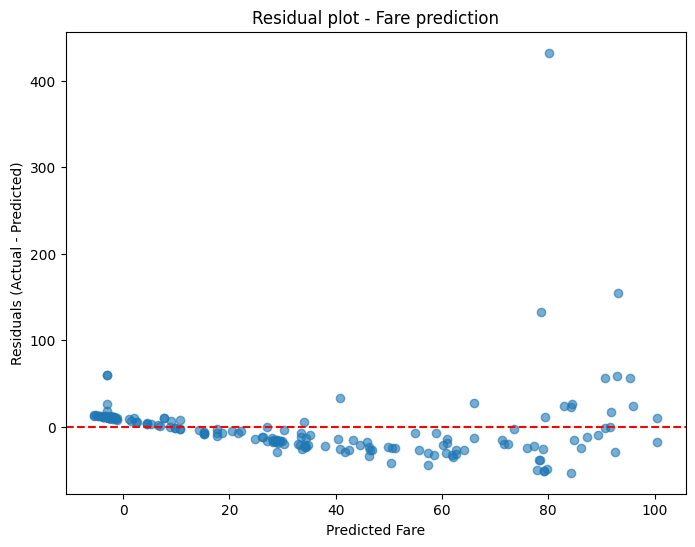

In [14]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt


reg_feature_cols = ["pclass", "sex", "age", "sibsp", "parch", "embarked", "survived"]

x_reg = df[reg_feature_cols]
y_reg = df["fare"]

#split
x_reg_train, x_reg_test, y_reg_train, y_reg_test = train_test_split(
    x_reg, y_reg, test_size=0.2, random_state=42
)

reg_numeric_features = ["pclass", "age", "sibsp", "parch", "survived"]
reg_categorical_features = ["sex", "embarked"]

reg_preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), reg_numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore"), reg_categorical_features)
])


x_reg_train_processed = reg_preprocessor.fit_transform(x_reg_train)
x_reg_test_processed = reg_preprocessor.transform(x_reg_test)

#Train linear regression
lin_reg = LinearRegression()
lin_reg.fit(x_reg_train_processed, y_reg_train)

y_reg_pred = lin_reg.predict(x_reg_test_processed)

#Metrics
mae = mean_absolute_error(y_reg_test, y_reg_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2 = r2_score(y_reg_test, y_reg_pred)

n = x_reg_test_processed.shape[0]
p = x_reg_test_processed.shape[1]
adjusted_r2 = 1- (1 - r2) * (n - 1) / (n - p -1)

print(f"MAE: {mae:.4f}")
print(f"RSME: {rmse:.4f}")
print(f"R2: {r2:.4f}")
print(f"Adjusted R2: {adjusted_r2:.4f}")

#residual plot
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(8, 6))
plt.scatter(y_reg_pred, residuals, alpha=0.6)
plt.axhline(y=0, color="red", linestyle="--")
plt.xlabel("Predicted Fare")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual plot - Fare prediction")
plt.savefig("residual_plot.png")
plt.show()

#Task-8

In [15]:
import pandas as pd

classification_table = pd.DataFrame(results)
print("--- classification Model Comparison ---")
print(classification_table)

#Regression Metrics Table
regression_table = pd.DataFrame([{
    "Model:": "Linear Regression (fare prediction)",
    "MAE": round(mae, 4),
    "RMSE": round(rmse, 4),
    "R2": round(r2, 4),
    "Adjusted_R2": round(adjusted_r2, 4)
}])

print("\n--- Regression Model Metrics ---")
print(regression_table)

--- classification Model Comparison ---
                 Model  Accuracy  Precision  Recall      F1     AUC
0  Logistic Regression    0.8090     0.7833  0.6912  0.7344  0.8610
1        Decision Tree    0.8090     0.8148  0.6471  0.7213  0.8560
2        Random Forest    0.8202     0.7812  0.7353  0.7576  0.8179

--- Regression Model Metrics ---
                                Model:      MAE     RMSE      R2  Adjusted_R2
0  Linear Regression (fare prediction)  21.0986  41.7021  0.3482       0.3091


#Task-9

In [16]:
import joblib
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", best_rf)
])

full_pipeline.fit(x_train, y_train)

joblib.dump(full_pipeline, "titanic_full_pipeline.joblib")
print("Pipeline saved successfully")

loaded_pipeline = joblib.load("titanic_full_pipeline.joblib")


sample_raw = x_test.iloc[:5]
predictions = loaded_pipeline.predict(sample_raw)


print("\n Sample raw input:")
print(sample_raw)
print("\npredictions from reloaded piprline:", predictions)
print("Actual values:", y_test.iloc[:5].values)

Pipeline saved successfully

 Sample raw input:
     pclass   sex   age  sibsp  parch    fare embarked
160       3  male  44.0      0      1  16.100        S
126       3  male  28.0      0      0   7.750        Q
428       3  male  28.0      0      0   7.750        Q
422       3  male  29.0      0      0   7.875        S
565       3  male  24.0      2      0  24.150        S

predictions from reloaded piprline: [0 0 0 0 0]
Actual values: [0 0 0 0 0]
